In this assignment, we work with a preprocessed dataset (imported as `d4`) to explore clustering and classification techniques. The steps we take are explained below:

---

### Data Preparation and Feature Scaling

First, we select a subset of features from our dataset – specifically, `"Gross_normalized"`, `"Runtime"`, and `"IMDB_Rating"`. To ensure that our features are on the same scale and to improve the performance of our algorithms, we normalize these values using the `StandardScaler`. This process is encapsulated in the `prepare_features` function, which not only extracts the desired columns but also returns the scaled feature matrix alongside the scaler object for potential future use.


In [5]:
from DataPreprocessed import d4
from DataPreprocessed import df

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
def prepare_features(data, feature_cols):
    """
    Select features and normalize them.
    Returns the scaled feature array and the scaler.
    """
    X = data[feature_cols]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler


In [6]:
features = ["Gross_normalized", "Runtime", "IMDB_Rating"]
X_scaled, scaler = prepare_features(d4, features)


### Determining the Optimal Number of Clusters

With our features scaled, we move on to clustering. But before clustering the data, we need to decide on the right number of clusters. We use two common techniques for this:

1. **Elbow Method:**
   The `compute_elbow_method` function applies K-Means clustering for a range of cluster numbers (from 2 to 10). It calculates the inertia (which is the sum of squared distances from each point to its assigned cluster center) for each value of *k*. By plotting these values, we can visually inspect the curve to find the "elbow" – a point where the rate of decrease sharply changes – suggesting an optimal number of clusters.

2. **Silhouette Scores:**
   The `compute_silhouette_scores` function computes the silhouette score for each number of clusters. This metric measures how similar an object is to its own cluster compared to other clusters. A higher silhouette score means that the clusters are well defined. A plot is generated to help us see which *k* value gives the best separation.

To help us decide, we also combine these two approaches by plotting them side by side using the `plot_elbow_and_silhouette` function. This dual perspective gives a clearer picture of the clustering quality.


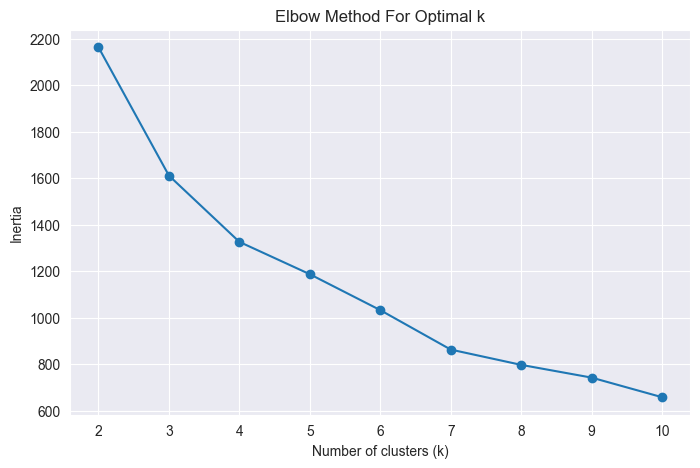

In [7]:
# ------------------------------
# Feature Preparation
# ------------------------------
def compute_elbow_method(X_scaled, k_range=range(2, 11)):
    """
    Computes inertia for a range of k values using K-Means.
    """
    inertia = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X_scaled)
        inertia.append(kmeans.inertia_)
    # Plot elbow curve
    plt.figure(figsize=(8, 5))
    plt.plot(list(k_range), inertia, marker='o')
    plt.title('Elbow Method For Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia')
    plt.show()
    return list(k_range), inertia
k_values, inertia = compute_elbow_method(X_scaled)


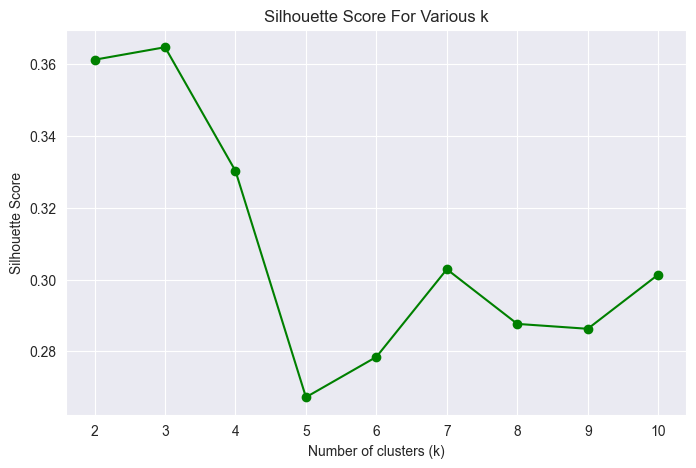

In [8]:
# 2. Elbow Method
def compute_silhouette_scores(X_scaled, k_range=range(2, 11)):
    """
    Computes silhouette scores for a range of k values.
    """
    sil_scores = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        sil_scores.append(score)
    # Plot silhouette scores
    plt.figure(figsize=(8, 5))
    plt.plot(list(k_range), sil_scores, marker='o', color='green')
    plt.title('Silhouette Score For Various k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.show()
    return list(k_range), sil_scores
k_values_sil, sil_scores = compute_silhouette_scores(X_scaled)


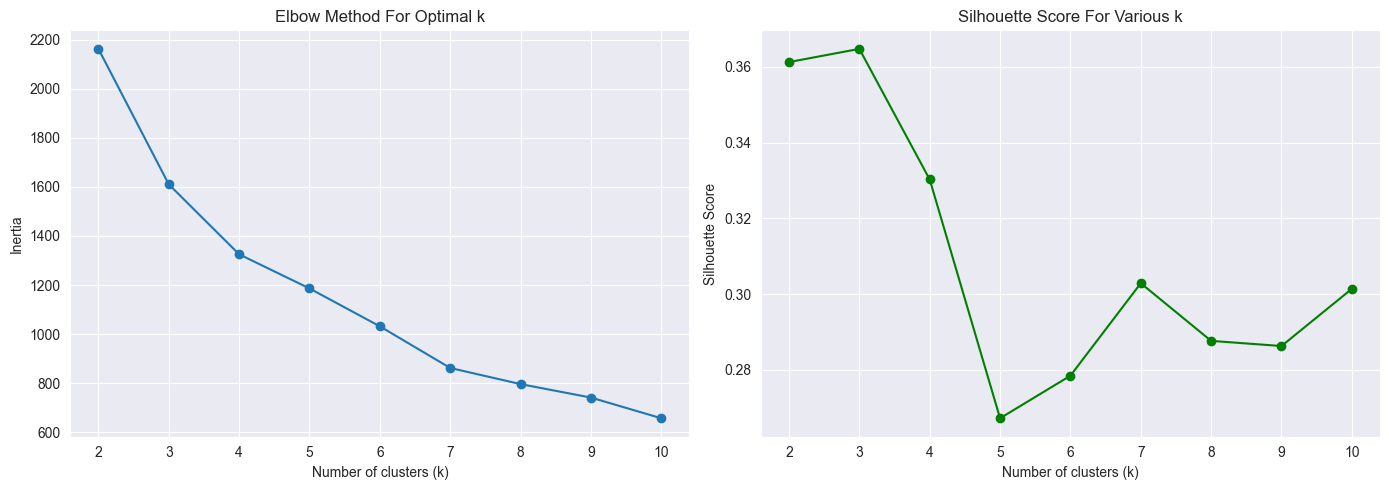

In [9]:
# 3. Silhouette Analysis
def plot_elbow_and_silhouette(k_values, inertia, sil_scores):
    """
    Plots the elbow method and silhouette scores side by side.
    """
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(k_values, inertia, marker='o')
    plt.title('Elbow Method For Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia')

    plt.subplot(1, 2, 2)
    plt.plot(k_values, sil_scores, marker='o', color='green')
    plt.title('Silhouette Score For Various k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.tight_layout()
    plt.show()
plot_elbow_and_silhouette(k_values, inertia, sil_scores)


### Clustering the Data with K-Means

After evaluating the elbow and silhouette plots, we choose an optimal number of clusters (in this case, 3) and perform K-Means clustering using the `perform_kmeans_clustering` function. The function returns both the fitted model and the assigned cluster labels. We then add these labels to our original DataFrame so we can later analyze the clusters.

To visualize the clustering results, we reduce our high-dimensional data into two principal components using PCA in the `visualize_clusters_pca` function. This step transforms our data into a 2D space, making it easier to plot and visually interpret how the clusters are distributed.

---

### Profiling the Clusters

Once clusters are formed, it is useful to understand what characterizes each group. The `display_cluster_profiles` function calculates and prints the mean values of our chosen features for each cluster. This profiling helps to identify trends or differences between clusters, such as one cluster having higher ratings or longer runtimes.



In [10]:
# ------------------------------
# Clustering - K-Means & PCA Visualization
# ------------------------------
def perform_kmeans_clustering(X_scaled, n_clusters):
    """
    Performs K-Means clustering on the scaled data.
    Returns the fitted model and cluster labels.
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    return kmeans, labels
optimal_k = 3  # Based on elbow and silhouette analysis
kmeans_model, cluster_labels = perform_kmeans_clustering(X_scaled, optimal_k)
d4['Cluster'] = cluster_labels

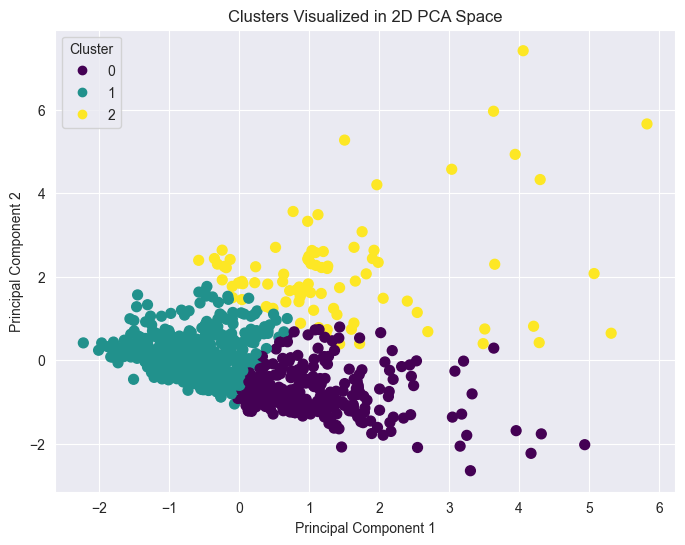

In [11]:
def visualize_clusters_pca(X_scaled, labels, title='Clusters Visualized in 2D PCA Space'):
    """
    Reduces data to 2 principal components using PCA and plots the clusters.
    Returns the PCA-transformed data.
    """
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.show()
    return X_pca
X_pca = visualize_clusters_pca(X_scaled, cluster_labels)


In [12]:
# ------------------------------
# Cluster Profiling
# ------------------------------
def display_cluster_profiles(data, feature_cols, cluster_col='Cluster'):
    """
    Displays the mean of selected features for each cluster.
    """
    profiles = data.groupby(cluster_col)[feature_cols].mean()
    print("Cluster Profiles:")
    print(profiles)
display_cluster_profiles(d4, features)

Cluster Profiles:
         Gross_normalized     Runtime  IMDB_Rating
Cluster                                           
0                0.037176  147.655405     2.172883
1                0.030364  110.427642     0.796611
2                0.344740  126.651685     1.522048


### Moving to Classification

The second part of the assignment involves a classification task. Here, we create a binary target variable with the `create_binary_target` function. By setting a threshold on the `"IMDB_Rating"` (for instance, 4), we classify each data point as either highly rated or not.

For the classification process, we select features (like normalized gross and runtime) and scale them appropriately using the `prepare_classification_data` function. This step ensures that our classification model has well-prepared inputs.

---

In [13]:
# ------------------------------
# Classification - Logistic Regression
# ------------------------------
def create_binary_target(data, rating_col='IMDB_Rating'):
    """
    Create a binary target variable 'Is_Highly_Rated' based on a threshold for imdb_rating.
    """
    result = data.copy()
    threshold = None
    # Calculate threshold if not provided
    if threshold is None:
        threshold = np.percentile(data[rating_col], 80)

    # Create binary target
    result['Is_Highly_Rated'] = (data[rating_col] >= threshold).astype(int)

    # Print distribution info
    total = len(result)
    pos_class = result['Is_Highly_Rated'].sum()
    print("\nTarget Distribution:")
    print(f"Threshold: {threshold:.2f}")
    print(f"Positive class (High rated): {pos_class} ({pos_class/total*100:.1f}%)")
    print(f"Negative class (Low rated): {total-pos_class} ({(total-pos_class)/total*100:.1f}%)")

    return result
classification_data = d4.copy()
classification_data['IMDB_Rating'] = df['IMDB_Rating']
classification_data = create_binary_target(classification_data, 'IMDB_Rating')
# print(classification_data['IMDB_Rating'])



Target Distribution:
Threshold: 8.10
Positive class (High rated): 322 (32.2%)
Negative class (Low rated): 678 (67.8%)


In [14]:
def prepare_classification_data(data, feature_cols=None):
    """
    Prepares features and target for classification.
    Checks for available columns and scales numeric features.
    """
    if feature_cols is None:
        # Get available numeric columns
        numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
        feature_cols = [col for col in ['Gross_normalized', 'Runtime'] if col in numeric_cols]

    # Verify columns exist
    available_cols = [col for col in feature_cols if col in data.columns]
    if not available_cols:
        raise ValueError("No valid feature columns found in data")

    # Create copy with available features
    X = data[available_cols].copy()
    y = data['Is_Highly_Rated']


    # Create and apply scaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Convert back to DataFrame to keep column names
    X_scaled = pd.DataFrame(X_scaled, columns=available_cols)

    print("\nFeatures used:", available_cols)
    print(f"Number of features: {len(available_cols)}")

    return X_scaled, y, scaler
X_cls_scaled, y_cls, scaler_cls = prepare_classification_data(
            classification_data,
            ['Gross_normalized', 'Runtime']
        )



Features used: ['Gross_normalized', 'Runtime']
Number of features: 2


### Logistic Regression Model

After preparing our features and target, we split the data into training and testing sets. The `run_logistic_regression` function then trains a logistic regression model on the training data. It makes predictions on the test set and evaluates the model's performance using several metrics: accuracy, precision, recall, and F1 score.

To give us a better visual understanding, the function generates:
- **Decision Boundary Plots:** Showing the distribution of actual vs. predicted values.
- **Probability Distribution Plot:** Illustrating how the predictions are spread.
- **Confusion Matrix:** Visualized as a heatmap, providing insight into model errors.

Finally, the model's coefficients (which indicate the importance of each feature) can be explored using the `display_model_coefficients` function, which neatly presents these values in a DataFrame.

---

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

def run_logistic_regression(X_train, y_train, X_test, y_test):
    """
    Trains and evaluates logistic regression model.
    Handles DataFrames and arrays properly.
    """
    # Initialize and train model
    logreg = LogisticRegression(random_state=42, max_iter=1000)
    logreg.fit(X_train, y_train)

    # Get predictions
    y_pred = logreg.predict(X_test)
    y_pred_proba = logreg.predict_proba(X_test)[:, 1]

    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0)
    }

    # Plotting
    plt.figure(figsize=(12, 4))

    # Plot 1: Scatter plot of features
    plt.subplot(1, 2, 1)
    X_test_array = X_test.to_numpy()
    plt.scatter(X_test_array[:, 0], X_test_array[:, 1], c=y_test, cmap='coolwarm')
    plt.xlabel(X_test.columns[0])
    plt.ylabel(X_test.columns[1])
    plt.title('Actual Values')

    # Plot 2: Predicted values
    plt.subplot(1, 2, 2)
    plt.scatter(X_test_array[:, 0], X_test_array[:, 1], c=y_pred, cmap='coolwarm')
    plt.xlabel(X_test.columns[0])
    plt.ylabel(X_test.columns[1])
    plt.title('Predicted Values')
    plt.tight_layout()
    plt.show()

    # Plot confusion matrix
    conf_mat = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return logreg, y_pred, metrics, conf_mat
X_train, X_test, y_train, y_test = train_test_split(
            X_cls_scaled,
            y_cls,
            test_size=0.2,
            random_state=42,
            stratify=y_cls
        )

# Check if we have both classes in training data
if len(np.unique(y_train)) < 1.5:
    print("Error: Not enough classes in training data")



# Train and evaluate model
# logreg_model, y_pred, metrics, conf_mat = run_logistic_regression(X_train, y_train, X_test, y_test)



Target Distribution:
Threshold: 8.10
Positive class (High rated): 322 (32.2%)
Negative class (Low rated): 678 (67.8%)


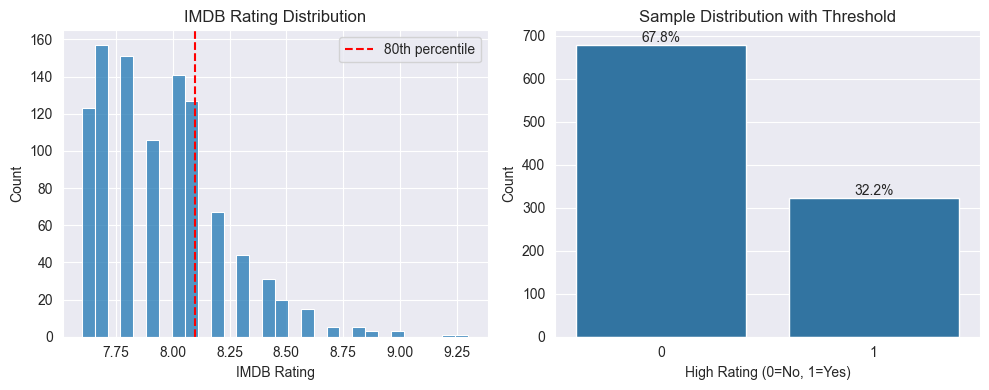


Threshold Statistics:
70th percentile threshold: 8.10
Movies above threshold: 322
Movies below threshold: 678
New threshold: 8.10
IMDB_Rating
False    678
True     322
Name: count, dtype: int64
Second debuggin

Updated Target Distribution:
Is_Highly_Rated
0    678
1    322
Name: count, dtype: int64

Features used: ['Gross_normalized', 'Runtime']
Number of features: 2
Target distribution:
Is_Highly_Rated
0    678
1    322
Name: count, dtype: int64

Training set distribution:
Is_Highly_Rated
0    480
1    220
Name: count, dtype: int64

Test set distribution:
Is_Highly_Rated
0    198
1    102
Name: count, dtype: int64


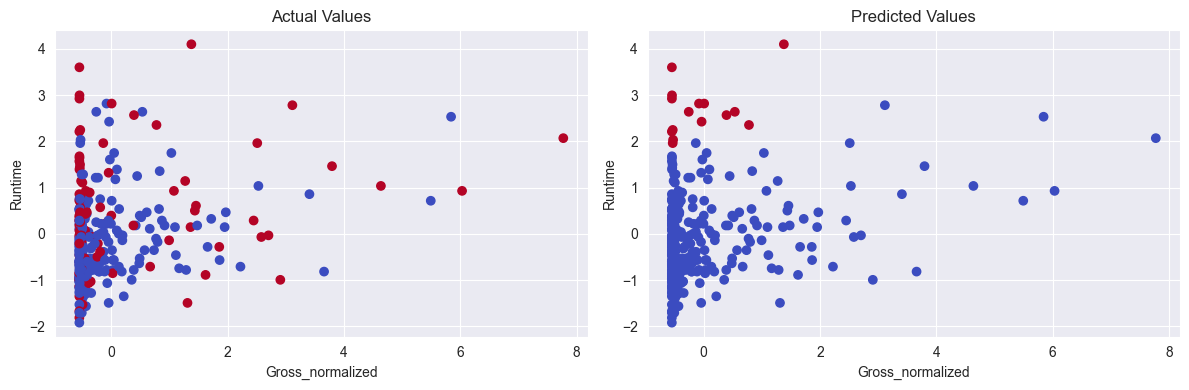

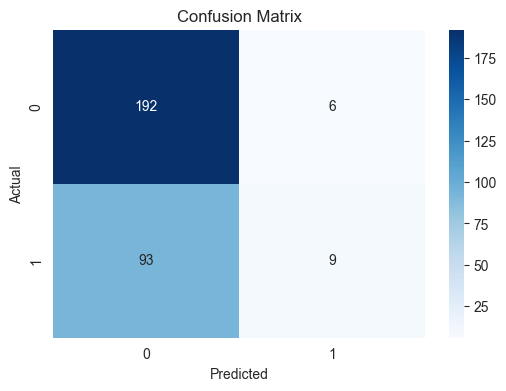

In [16]:
def find_rating_threshold(data, percentile):
    """
    Find the IMDB rating threshold at specified percentile.
    Returns the threshold and creates visualization of the distribution.
    """
    # Calculate threshold
    threshold = np.percentile(data['IMDB_Rating'], percentile)

    # Visualize distribution
    plt.figure(figsize=(10, 4))

    # Plot 1: Distribution with threshold
    plt.subplot(1, 2, 1)
    sns.histplot(data=data, x='IMDB_Rating', bins=30)
    plt.axvline(x=threshold, color='r', linestyle='--', label=f'{percentile}th percentile')
    plt.title('IMDB Rating Distribution')
    plt.xlabel('IMDB Rating')
    plt.ylabel('Count')
    plt.legend()

    # Plot 2: Ratings split
    plt.subplot(1, 2, 2)
    is_high = (data['IMDB_Rating'] >= threshold).astype(int)
    sns.countplot(x=is_high)
    plt.title('Sample Distribution with Threshold')
    plt.xlabel('High Rating (0=No, 1=Yes)')
    plt.ylabel('Count')

    # Add percentage labels
    total = len(data)
    for i in range(2):
        count = (is_high == i).sum()
        pct = count/total*100
        plt.text(i, count, f'{pct:.1f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"\nThreshold Statistics:")
    print(f"70th percentile threshold: {threshold:.2f}")
    print(f"Movies above threshold: {(data['IMDB_Rating'] >= threshold).sum()}")
    print(f"Movies below threshold: {(data['IMDB_Rating'] < threshold).sum()}")

    return threshold

# Find threshold and update target variable
classification_data = d4.copy()
classification_data['IMDB_Rating'] = df['IMDB_Rating']
classification_data = create_binary_target(classification_data, 'IMDB_Rating')
threshold = find_rating_threshold(classification_data, percentile=80)
print(f"New threshold: {threshold:.2f}")
print((classification_data['IMDB_Rating'] >= threshold).value_counts())


# Create binary target with new threshold
classification_data['Is_Highly_Rated'] = (classification_data['IMDB_Rating'] >= threshold).astype(int)
print("Second debuggin\n")
print("Updated Target Distribution:")
print(classification_data['Is_Highly_Rated'].value_counts())


# Retrain model with new threshold
X_cls_scaled, y_cls, scaler_cls = prepare_classification_data(
    classification_data,
    ['Gross_normalized', 'Runtime']
)
print("Target distribution:")
print(y_cls.value_counts())


X_train, X_test, y_train, y_test = train_test_split(
    X_cls_scaled,
    y_cls,
    test_size=0.3,
    random_state=42,
)
print("\nTraining set distribution:")
print(y_train.value_counts())

print("\nTest set distribution:")
print(y_test.value_counts())


# Train and evaluate model with new threshold
logreg_model, y_pred, metrics, conf_mat = run_logistic_regression(X_train, y_train, X_test, y_test)


Feature Coefficients:
Runtime: 0.394
Gross_normalized: -0.097


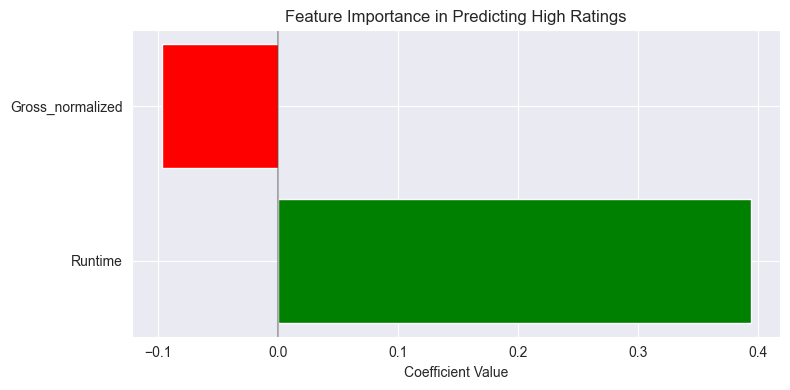

In [17]:
def display_model_coefficients(model, feature_cols):
    """
    Displays and visualizes the model coefficients for feature importance.
    """
    # Get coefficients
    coefficients = model.coef_[0]

    # Create DataFrame for coefficients
    coef_df = pd.DataFrame({
        'Feature': feature_cols,
        'Coefficient': coefficients
    })
    coef_df = coef_df.sort_values('Coefficient', ascending=False)

    # Plot coefficients
    plt.figure(figsize=(8, 4))
    colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
    plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.title('Feature Importance in Predicting High Ratings')
    plt.xlabel('Coefficient Value')

    # Print coefficients
    print("\nFeature Coefficients:")
    for _, row in coef_df.iterrows():
        print(f"{row['Feature']}: {row['Coefficient']:.3f}")

    plt.tight_layout()
    plt.show()

    return coef_df

# Display coefficients
feature_importance = display_model_coefficients(
    logreg_model,
    ['Gross_normalized', 'Runtime']
)

In [18]:
def analyze_model_performance(y_test, y_pred, metrics, conf_mat):
    """
    Analyze and display model performance metrics and insights.
    """
    print("\nModel Performance Metrics:")
    for metric, value in metrics.items():
        print(f"{metric.capitalize()}: {value:.3f}")

    # Calculate additional metrics
    tn, fp, fn, tp = conf_mat.ravel()
    specificity = tn / (tn + fp)
    print(f"Specificity: {specificity:.3f}")

    print("\nConfusion Matrix Breakdown:")
    print(f"True Positives: {tp}")
    print(f"True Negatives: {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")

# Run analysis
analyze_model_performance(y_test, y_pred, metrics, conf_mat)


Model Performance Metrics:
Accuracy: 0.670
Precision: 0.600
Recall: 0.088
F1_score: 0.154
Specificity: 0.970

Confusion Matrix Breakdown:
True Positives: 9
True Negatives: 192
False Positives: 6
False Negatives: 93


# Comparing Insights from Clustering and Classification

In this section, we compare the insights obtained from both our clustering and classification analyses to evaluate whether any of the groups (clusters) appear more relevant or distinctive.

### What We Explore:
- **Cluster Profiles:** We look at the average IMDB rating and the proportion of movies classified as "highly rated" (using our binary target) in each cluster.
- **Rating Distributions:** By visualizing the spread of IMDB ratings across clusters, we can assess the central tendency and variability.
- **Class Balance Within Clusters:** We also compare the counts of highly rated vs. not highly rated movies in each cluster.

These analyses help us identify clusters that might represent a more promising segment (e.g., clusters with higher average ratings or a higher fraction of highly rated movies) and offer insights on the quality of our clustering relative to the classification task.

### Future Directions and Improvements:
- **Feature Engineering:** Incorporate more features such as genre, director, or release year to enrich the insights.
- **Advanced Clustering Methods:** Experiment with clustering methods beyond K-Means (e.g., hierarchical clustering or Gaussian Mixture Models) to capture more nuanced structures.
- **Model Enhancement:** Evaluate additional classification algorithms (e.g., Random Forests, SVM) and use cross-validation to improve robustness.
- **Integration of Analyses:** Merge insights from clustering and classification to target segments that are both distinct in their characteristics and have a higher likelihood of being highly rated.


C:\Users\tudor\AppData\Local\Temp\ipykernel_23648\330051283.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='mean_rating', data=cluster_summary, palette='viridis')
C:\Users\tudor\AppData\Local\Temp\ipykernel_23648\330051283.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='fraction_highly_rated', data=cluster_summary, palette='viridis')


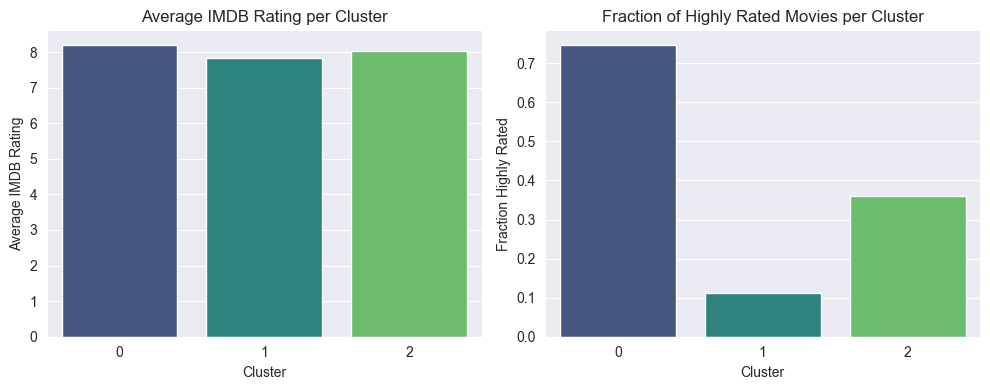

C:\Users\tudor\AppData\Local\Temp\ipykernel_23648\330051283.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='IMDB_Rating', data=classification_data, palette='viridis')


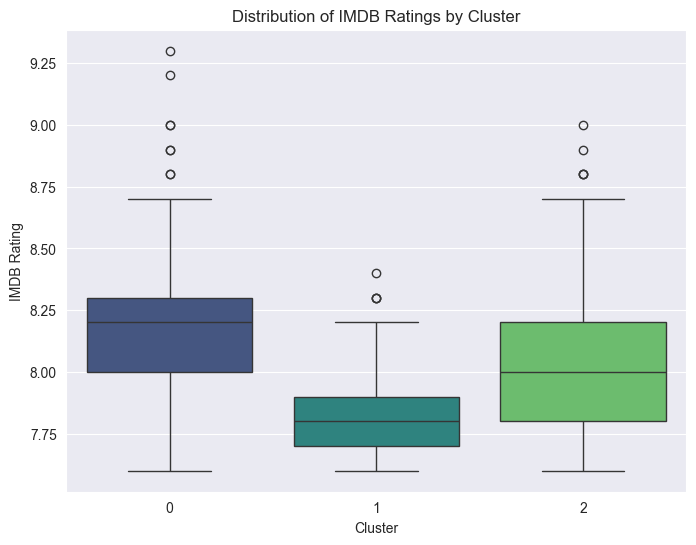

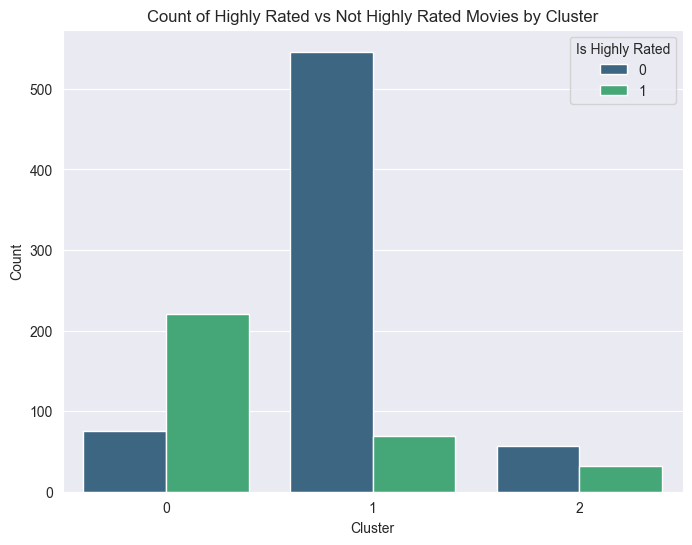

In [19]:
# Comparison of Insights from Clustering and Classification

import seaborn as sns
import matplotlib.pyplot as plt

# Assume classification_data is a copy of d4 that contains both the 'Cluster' column (from clustering)
# and the binary target column 'Is_Highly_Rated' (from classification)

# Group data by clusters to compute summary statistics:
cluster_summary = classification_data.groupby('Cluster').agg(
    count=('IMDB_Rating', 'size'),
    mean_rating=('IMDB_Rating', 'mean'),
    fraction_highly_rated=('Is_Highly_Rated', 'mean')
).reset_index()

# Plot 1: Average IMDB Rating per Cluster
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(x='Cluster', y='mean_rating', data=cluster_summary, palette='viridis')
plt.title('Average IMDB Rating per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average IMDB Rating')

# Plot 2: Fraction of Highly Rated Movies per Cluster
plt.subplot(1, 2, 2)
sns.barplot(x='Cluster', y='fraction_highly_rated', data=cluster_summary, palette='viridis')
plt.title('Fraction of Highly Rated Movies per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Fraction Highly Rated')

plt.tight_layout()
plt.show()

# Plot 3: Distribution of IMDB Ratings by Cluster using a Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Cluster', y='IMDB_Rating', data=classification_data, palette='viridis')
plt.title('Distribution of IMDB Ratings by Cluster')
plt.xlabel('Cluster')
plt.ylabel('IMDB Rating')
plt.show()

# Plot 4: Count of Highly Rated vs. Not Highly Rated Movies per Cluster
plt.figure(figsize=(8, 6))
sns.countplot(x='Cluster', hue='Is_Highly_Rated', data=classification_data, palette='viridis')
plt.title('Count of Highly Rated vs Not Highly Rated Movies by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Is Highly Rated', loc='upper right')
plt.show()

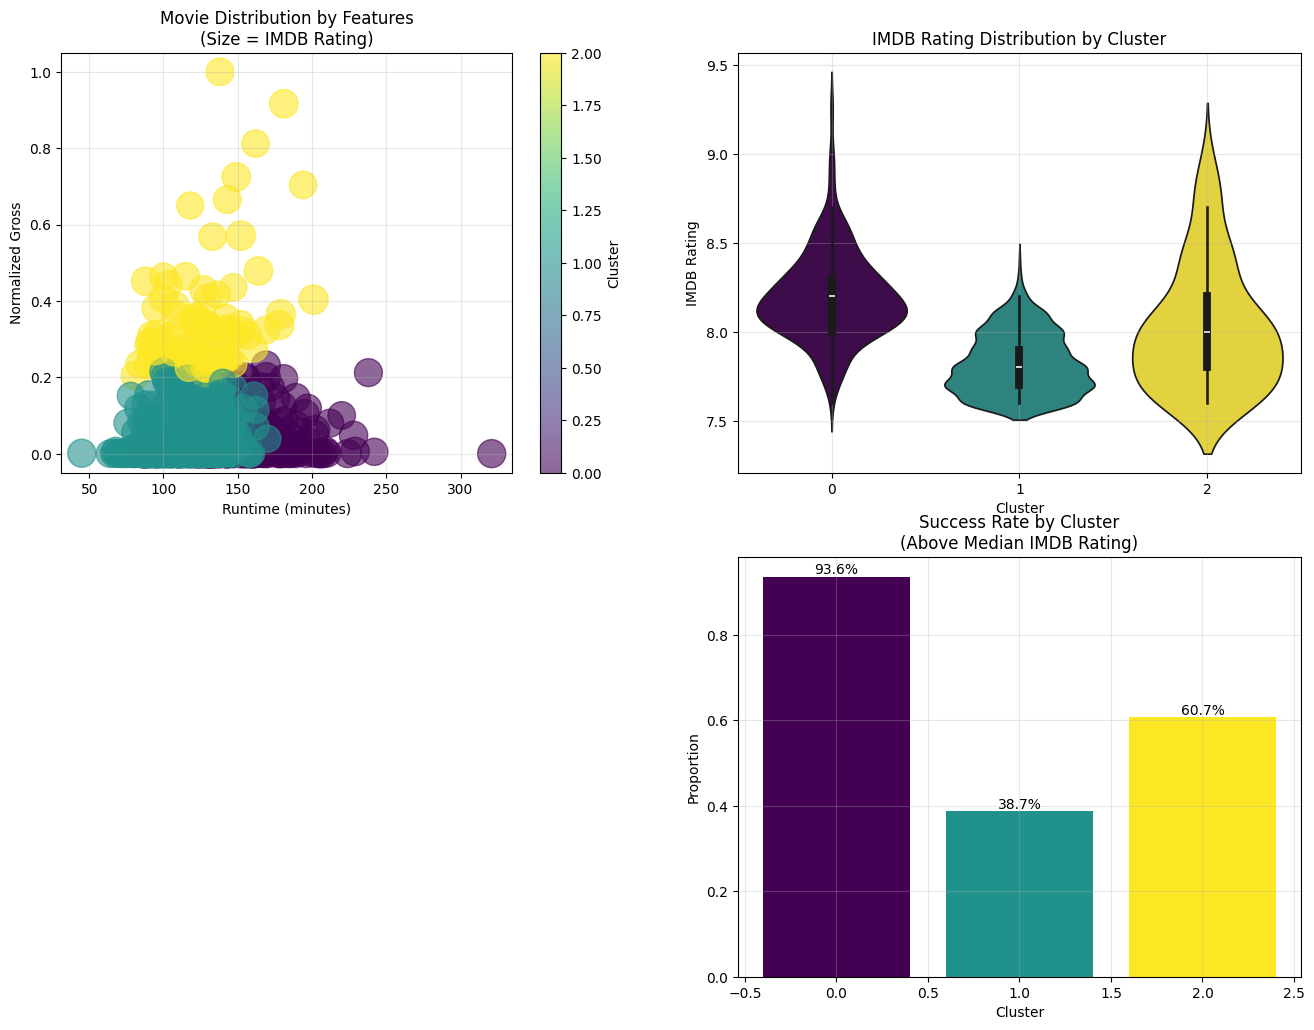


Cluster Summary Statistics:
         Count  Avg Rating  Rating STD  Avg Runtime  Avg Gross
Cluster                                                       
0          296        8.20        0.25       147.66       0.04
1          615        7.82        0.17       110.43       0.03
2           89        8.02        0.35       126.65       0.34


In [20]:
def analyze_clusters_and_ratings(data):
    """
    Creates comprehensive visualizations comparing clusters and ratings.
    """
    # Set the style to a valid matplotlib style
    plt.style.use('default')

    # Create figure with subplots
    fig = plt.figure(figsize=(16, 12))

    # 1. Feature Relationships with Clusters
    plt.subplot(2, 2, 1)
    scatter = plt.scatter(data['Runtime'],
                         data['Gross_normalized'],
                         c=data['Cluster'],
                         s=data['IMDB_Rating']*50,
                         alpha=0.6,
                         cmap='viridis')
    plt.colorbar(scatter, label='Cluster')
    plt.title('Movie Distribution by Features\n(Size = IMDB Rating)')
    plt.xlabel('Runtime (minutes)')
    plt.ylabel('Normalized Gross')
    plt.grid(True, alpha=0.3)

    # 2. Rating Distribution by Cluster
    plt.subplot(2, 2, 2)
    sns.violinplot(data=data,
                  x='Cluster',
                  y='IMDB_Rating',
                  hue='Cluster',
                  palette='viridis',
                  legend=False)
    plt.title('IMDB Rating Distribution by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('IMDB Rating')
    plt.grid(True, alpha=0.3)

    # # 3. Cluster Composition
    # plt.subplot(2, 2, 3)
    # cluster_stats = data.groupby('Cluster').agg({
    #     'Runtime': 'mean',
    #     'Gross_normalized': 'mean',
    #     'IMDB_Rating': 'mean'
    # }).round(2)
    #
    # cluster_stats_normalized = (cluster_stats - cluster_stats.min()) / (cluster_stats.max() - cluster_stats.min())
    # cluster_stats_normalized.plot(kind='bar')
    # plt.title('Normalized Feature Comparison by Cluster')
    # plt.xlabel('Cluster')
    # plt.ylabel('Normalized Value')
    # plt.legend(bbox_to_anchor=(1.05, 1))
    # plt.grid(True, alpha=0.3)

    # 4. Success Rate by Cluster
    plt.subplot(2, 2, 4)
    high_rated = data['IMDB_Rating'] >= data['IMDB_Rating'].median()
    cluster_rating = pd.crosstab(data['Cluster'], high_rated)
    cluster_rating_pct = cluster_rating.div(cluster_rating.sum(axis=1), axis=0)

    bars = plt.bar(range(len(cluster_rating_pct)),
                  cluster_rating_pct[True],
                  color=plt.cm.viridis(np.linspace(0, 1, len(cluster_rating_pct))))

    # Add percentage labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}',
                ha='center', va='bottom')

    plt.title('Success Rate by Cluster\n(Above Median IMDB Rating)')
    plt.xlabel('Cluster')
    plt.ylabel('Proportion')
    plt.grid(True, alpha=0.3)

    # Adjust layout and display
   # plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\nCluster Summary Statistics:")
    summary = data.groupby('Cluster').agg({
        'IMDB_Rating': ['count', 'mean', 'std'],
        'Runtime': 'mean',
        'Gross_normalized': 'mean'
    }).round(2)

    # Rename columns for clarity
    summary.columns = ['Count', 'Avg Rating', 'Rating STD', 'Avg Runtime', 'Avg Gross']
    print(summary)
# Call the improved function
analyze_clusters_and_ratings(classification_data)

### An Alternative Clustering Approach: DBSCAN

In addition to K-Means, we briefly explore another clustering method, DBSCAN, through the `run_dbscan_clustering` function. DBSCAN works differently by identifying clusters based on the density of data points. This method is particularly useful when clusters have irregular shapes and provides a contrast to the centroid-based approach of K-Means.

---

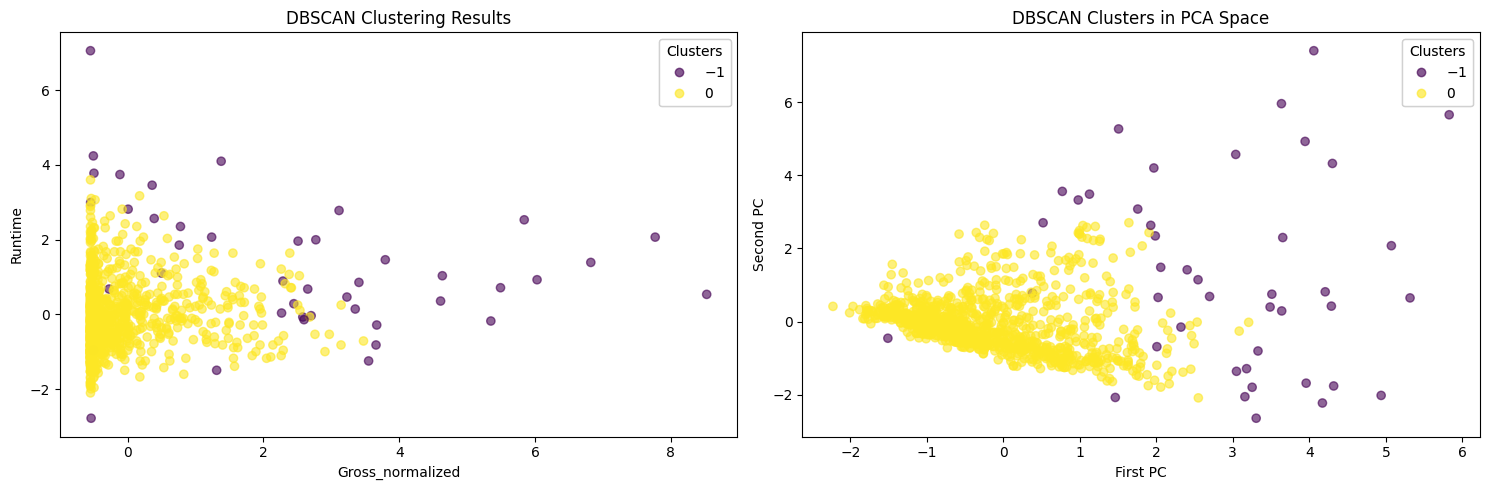


DBSCAN Clustering Results:
Number of clusters: 1
Number of noise points: 43
Points per cluster (including noise):
noise points: 43 points
cluster 0: 957 points


In [21]:
from sklearn.cluster import DBSCAN

def run_and_plot_dbscan(X_scaled, eps=0.5, min_samples=5, feature_names=None):
    """
    Runs DBSCAN clustering and creates visualizations of the results.
    """
    # Run DBSCAN
    if feature_names is None:
        feature_names = ['Gross_normalized', 'Runtime']
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    # Count number of clusters (excluding noise points labeled as -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    # Create visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Original feature space plot
    scatter1 = ax1.scatter(X_scaled[:, 0], X_scaled[:, 1],
                          c=labels, cmap='viridis',
                          alpha=0.6)
    ax1.set_title('DBSCAN Clustering Results')
    ax1.set_xlabel(feature_names[0])
    ax1.set_ylabel(feature_names[1])
    legend1 = ax1.legend(*scatter1.legend_elements(),
                        title="Clusters",
                        loc="upper right")
    ax1.add_artist(legend1)

    # PCA visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1],
                          c=labels, cmap='viridis',
                          alpha=0.6)
    ax2.set_title('DBSCAN Clusters in PCA Space')
    ax2.set_xlabel('First PC')
    ax2.set_ylabel('Second PC')
    legend2 = ax2.legend(*scatter2.legend_elements(),
                        title="Clusters",
                        loc="upper right")
    ax2.add_artist(legend2)

    plt.tight_layout()
    plt.show()

    # Print clustering results
    print(f"\nDBSCAN Clustering Results:")
    print(f"Number of clusters: {n_clusters}")
    print(f"Number of noise points: {n_noise}")
    print(f"Points per cluster (including noise):")
    for label in sorted(set(labels)):
        count = list(labels).count(label)
        status = "noise points" if label == -1 else f"cluster {label}"
        print(f"{status}: {count} points")

    return labels

# Run DBSCAN clustering
dbscan_labels = run_and_plot_dbscan(
    X_scaled,
    eps=0.75,  # Adjusted epsilon for better clustering
    min_samples=5  # Minimum points to form a cluster
)

In [22]:
# from sklearn.model_selection import train_test_split
#
#
# def main():
#     """Main execution flow for movie data analysis."""
#     try:
#         # Define features for analysis
#         features = ["Gross_normalized", "Runtime", "IMDB_Rating"]
#
#         # 1. Clustering Analysis
#         print("\n=== Clustering Analysis ===")
#         X_scaled, scaler = prepare_features(d4, features)
#
#         # Determine optimal k
#         k_values, inertia = compute_elbow_method(X_scaled)
#         k_values_sil, sil_scores = compute_silhouette_scores(X_scaled)
#         plot_elbow_and_silhouette(k_values, inertia, sil_scores)
#
#         # Perform clustering
#         optimal_k = 3  # Based on elbow and silhouette analysis
#         kmeans_model, cluster_labels = perform_kmeans_clustering(X_scaled, optimal_k)
#         d4['Cluster'] = cluster_labels
#
#         # Visualize clusters
#         X_pca = visualize_clusters_pca(X_scaled, cluster_labels)
#         display_cluster_profiles(d4, features)
#
#         # 2. Classification Analysis
#         print("\n=== Classification Analysis ===")
#         # Create binary target with appropriate threshold
#         classification_data = d4.copy()
#         classification_data = create_binary_target(classification_data, 'IMDB_Rating', threshold=4)
#
#         # Check class distribution
#         class_dist = classification_data['Is_Highly_Rated'].value_counts()
#         print("\nClass Distribution:")
#         print(class_dist)
#
#         if len(class_dist) < 2 or class_dist.min() < 10:
#             print("Warning: Insufficient data for classification")
#             return
#
#         # Prepare classification features
#         X_cls_scaled, y_cls, scaler_cls = prepare_classification_data(
#             classification_data,
#             ['Gross_normalized', 'Runtime']
#         )
#
#         # Split data ensuring both classes are present in train and test sets
#         X_train, X_test, y_train, y_test = train_test_split(
#             X_cls_scaled,
#             y_cls,
#             test_size=0.3,
#             random_state=42,
#             stratify=y_cls
#         )
#
#         # Check if we have both classes in training data
#         if len(np.unique(y_train)) < 2:
#             print("Error: Not enough classes in training data")
#             return
#
#         # Train and evaluate model
#         logreg_model, y_pred, metrics, conf_mat = run_logistic_regression(
#             X_train, y_train, X_test, y_test
#         )
#
#         # Display results
#         print("\nModel Performance:")
#         for metric, value in metrics.items():
#             print(f"{metric.capitalize()}: {value:.3f}")
#
#         # Plot confusion matrix
#         plt.figure(figsize=(6, 4))
#         sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
#         plt.title('Confusion Matrix')
#         plt.xlabel('Predicted')
#         plt.ylabel('Actual')
#         plt.show()
#
#     except Exception as e:
#         print(f"Error occurred: {str(e)}")
#         raise
#
# if __name__ == "__main__":
#     main()

### Summary

Overall, the assignment guides us through the process of:
- **Preparing and normalizing the data**
- **Identifying the optimal number of clusters**
- **Clustering with K-Means and visualizing the results using PCA**
- **Profiling the clusters to understand their characteristics**
- **Creating a binary classification target and training a logistic regression model**
- **Evaluating model performance with visual and numerical metrics**
- **Exploring an alternative clustering technique with DBSCAN**

This systematic approach not only addresses the technical requirements but also helps build an intuitive understanding of clustering and classification methods.